# Relabelling Existing General Dataset

In this work, I adapt the trained seq2seq model that maps Chinese characters to their respective pinyin tokens. The goal is to map the character sequences of the new dataset related to various everyday life topics to the pinyin sequences.

# Load Original Dataset

In [1]:
from datasets import load_dataset

ds = load_dataset("Duyu/Pinyin-Hanzi")

README.md:   0%|          | 0.00/223 [00:00<?, ?B/s]

pinyin2hanzi.csv:   0%|          | 0.00/78.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1646553 [00:00<?, ? examples/s]

In [2]:
text_column = '我们试试看！'
pinyin_column = 'wo3 men shi4 shi4 kan4 ！'

dataset = ds['train'].rename_columns({
    text_column: 'text',
    pinyin_column: 'pinyin'
})
dataset

Dataset({
    features: ['text', 'pinyin'],
    num_rows: 1646553
})

In [3]:
for x in dataset:
    print(x)
    break

{'text': '末広雅里', 'pinyin': 'mo4 guang3 ya3 li3'}


## Load Auxiliary Dataset

In [4]:
pinyin_tokens = set()

with open("", "r") as pinyin_dataset:
    pinyin_data = pinyin_dataset.read()

    for token in pinyin_data.split():
        pinyin_tokens.add(token)

In [5]:
'ma' in pinyin_tokens

True

In [6]:
'cat' in pinyin_tokens

False

**1. Build Vocabulary**

In [7]:
# Build character and pinyin vocabularies from the dataset

from tqdm import tqdm

def build_vocab(dataset):
    """
    dataset: list of dicts with keys 'text' (str) and 'pinyin' (str)
    returns:
        char2idx, idx2char, pinyin2idx, idx2pinyin
    """
    # Collect all characters and pinyin tokens
    chars = set()
    pinyins = set()
    
    for sample in tqdm(dataset):
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        # Add each character from text
        for ch in text:
            chars.add(ch)
        
        # Split pinyin by space and add each token
        tokens = pinyin_str.split()
        for tok in tokens:
            if (
                (tok[-1].isdigit() and tok[:-1] in pinyin_tokens) or \
                (tok[-1].isalpha() and tok in pinyin_tokens)
            ):
                pinyins.add(tok)
    
    # Convert to sorted lists for deterministic order (optional)
    char_list = ['<UNK>', '<PAD>'] + sorted(chars)
    pinyin_list = ['<UNK>', '<PAD>'] + sorted(pinyins)
    
    # Create mappings
    char2idx = {ch: idx for idx, ch in enumerate(char_list)}
    idx2char = {idx: ch for idx, ch in enumerate(char_list)}
    
    pinyin2idx = {p: idx for idx, p in enumerate(pinyin_list)}
    idx2pinyin = {idx: p for idx, p in enumerate(pinyin_list)}
    
    print(f"Number of unique characters (including specials): {len(char_list)}")
    print(f"Number of unique pinyin tokens (including specials): {len(pinyin_list)}")

    return char2idx, idx2char, pinyin2idx, idx2pinyin

In [8]:
char2idx, idx2char, pinyin2idx, idx2pinyin = build_vocab(dataset)

100%|██████████| 1646553/1646553 [00:42<00:00, 39020.57it/s]

Number of unique characters (including specials): 21066
Number of unique pinyin tokens (including specials): 1491


**2. Preprocess Dataset with Mappings**

In [9]:
# Convert text and pinyin to index sequences, filtering invalid pinyin

def preprocess_dataset_filtered(dataset, char2idx, pinyin2idx):
    skipped = 0
    total = 0
    
    for sample in tqdm(dataset):
        total += 1
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        chars = list(text)
        pinyin_tokens = pinyin_str.split()
        
        # Skip if lengths don't match
        if len(chars) != len(pinyin_tokens):
            skipped += 1
            continue
        
        # Skip if any invalid pinyin token
        if any(tok not in pinyin2idx for tok in pinyin_tokens):
            skipped += 1
            continue
        
        # Valid sample - yield the indices
        char_idxs = [char2idx.get(ch, 0) for ch in chars]
        pinyin_idxs = [pinyin2idx[tok] for tok in pinyin_tokens]
        
        yield char_idxs, pinyin_idxs
    
    print(f"Processed {total} samples, skipped {skipped} with invalid pinyin")

In [10]:
preprocessed_dataset = preprocess_dataset_filtered(dataset, char2idx, pinyin2idx)

In [11]:
text_seqs = []
pinyin_seqs = []

for char_idxs, pinyin_idxs in preprocessed_dataset:
    text_seqs.append(char_idxs)
    pinyin_seqs.append(pinyin_idxs)

100%|██████████| 1646553/1646553 [00:50<00:00, 32676.22it/s]

Processed 1646553 samples, skipped 117692 with invalid pinyin


# Define BiLSTM Seq2Seq Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTMForPinyin(nn.Module):
    """
    BiLSTM model for predicting pinyin tokens from character sequences.
    For each character in the input, it outputs a probability distribution over pinyin tokens.
    """
    def __init__(self, vocab_size_char, vocab_size_pinyin, embedding_dim, hidden_dim, num_layers=2, dropout=0.3, pad_idx=1):
        """
        Args:
            vocab_size_char: number of unique characters (including <PAD> and <UNK>)
            vocab_size_pinyin: number of unique pinyin tokens (including <PAD> and <UNK>)
            embedding_dim: dimension of character embeddings
            hidden_dim: dimension of LSTM hidden states (will be doubled due to bidirectionality)
            num_layers: number of LSTM layers
            dropout: dropout probability (applied between LSTM layers and after LSTM)
            pad_idx: index of the padding token (used to ignore padding in loss)
        """
        super().__init__()
        self.embedding = nn.Embedding(vocab_size_char, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # After BiLSTM, hidden_dim * 2 because bidirectional
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size_pinyin)
        self.pad_idx = pad_idx

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len) tensor of character indices
        Returns:
            logits: (batch_size, seq_len, vocab_size_pinyin)
        """
        # Embedding: (batch_size, seq_len, embedding_dim)
        emb = self.embedding(x)
        
        # LSTM: outputs (batch_size, seq_len, hidden_dim * 2)
        lstm_out, _ = self.lstm(emb)
        
        # Apply dropout
        lstm_out = self.dropout(lstm_out)
        
        # Linear layer to produce logits for each pinyin token
        logits = self.fc(lstm_out)  # (batch_size, seq_len, vocab_size_pinyin)
        
        return logits

    def predict(self, x):
        """Returns predicted pinyin indices (no grad)"""
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            preds = torch.argmax(logits, dim=-1)  # (batch_size, seq_len)
        return preds

## Load the Best Model for Testing

In [13]:
import torch
import torch.nn as nn

vocab_size_char = len(char2idx)
vocab_size_pinyin = len(pinyin2idx)
embedding_dim = 100
hidden_dim = 256
num_layers = 2
dropout = 0.3
pad_idx = 1  # <PAD> token index

In [14]:
text2pinyin = BiLSTMForPinyin(
    vocab_size_char=vocab_size_char,
    vocab_size_pinyin=vocab_size_pinyin,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=pad_idx
)

# Load the best saved weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
text2pinyin.load_state_dict(torch.load('', map_location=device))
text2pinyin.to(device)
text2pinyin.eval()

BiLSTMForPinyin(
  (embedding): Embedding(21066, 100, padding_idx=1)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1491, bias=True)
)

In [15]:
def predict_pinyin(sentence, model, char2idx, idx2pinyin, device):
    """
    Predict pinyin sequence for a single Chinese sentence.
    Args:
        sentence: string of Chinese characters (no spaces)
        model: trained BiLSTMForPinyin model
        char2idx: char to index mapping
        idx2pinyin: index to pinyin token mapping
        device: torch device
    Returns:
        pinyin_tokens: list of predicted pinyin strings
    """
    # Tokenize into characters
    chars = list(sentence)
    # Convert to indices, use 0 for unknown characters
    indices = [char2idx.get(ch, 0) for ch in chars]
    # Create tensor with batch dimension
    input_tensor = torch.tensor([indices], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)           # (1, seq_len, vocab_pinyin)
        pred_indices = logits.argmax(dim=-1)   # (1, seq_len)
    
    # Convert indices to pinyin tokens
    pred_tokens = [idx2pinyin[idx.item()] for idx in pred_indices[0]]
    return pred_tokens

In [16]:
# Test sentences (example Chinese sentences)
test_sentences = [
    "你好世界",
    "今天天气不错",
    "我喜欢吃苹果",
    "机器学习很有趣",
    "零二三四五六七八九十百千万亿",
    "末広雅里"   # from the dataset example
]

print("Testing model on example sentences:\n")
for sentence in test_sentences:
    predicted = predict_pinyin(sentence, text2pinyin, char2idx, idx2pinyin, device)
    print(f"Input  : {sentence}")
    print(f"Output : {' '.join(predicted)}")
    print()

Testing model on example sentences:

Input  : 你好世界
Output : ni3 hao3 shi4 jie4

Input  : 今天天气不错
Output : jin1 tian1 tian1 qi4 bu4 cuo4

Input  : 我喜欢吃苹果
Output : wo3 xi3 huan1 chi1 ping2 guo3

Input  : 机器学习很有趣
Output : ji1 qi4 xue2 xi2 hen3 you3 qu4

Input  : 零二三四五六七八九十百千万亿
Output : ling2 er4 san1 si4 wu3 liu4 qi1 ba1 jiu3 shi2 bai3 qian1 wan4 yi4

Input  : 末広雅里
Output : mo4 guang3 ya3 li3



# Load New Target Dataset

In [17]:
!git clone https://huggingface.co/datasets/AIxBlock/Chinese-short-sentences

Cloning into 'Chinese-short-sentences'...
remote: Enumerating objects: 24, done.
remote: Total 24 (delta 0), reused 0 (delta 0), pack-reused 24 (from 1)
Receiving objects: 100% (24/24), 8.00 KiB | 1.60 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Filtering content: 100% (2/2), 46.20 MiB | 32.38 MiB/s, done.


In [18]:
!ls Chinese-short-sentences

'Chinese-short-utterances-lot1- 282358 Sentences.xlsx'	 README.md
'Chinese-short-utterances-lot2-270675 Sentences.xlsx'


In [19]:
import pandas as pd

df = pd.read_excel("Chinese-short-sentences/Chinese-short-utterances-lot1- 282358 Sentences.xlsx")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282358 entries, 0 to 282357
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Sr No      282358 non-null  int64 
 1   Utterance  282358 non-null  object
 2   Status     282358 non-null  object
 3   Language   239620 non-null  object
 4   Topics     240274 non-null  object
dtypes: int64(1), object(4)
memory usage: 10.8+ MB


<Axes: >

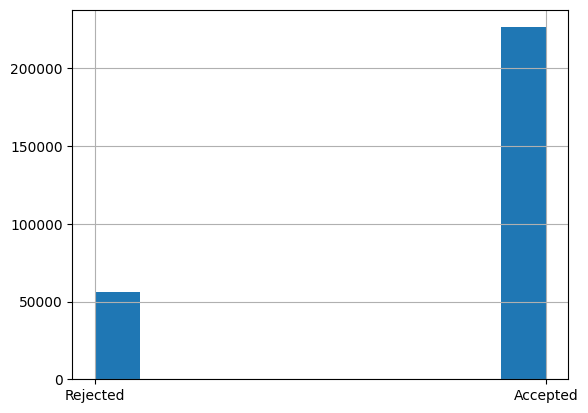

In [21]:
df['Status'].hist()

<Axes: >

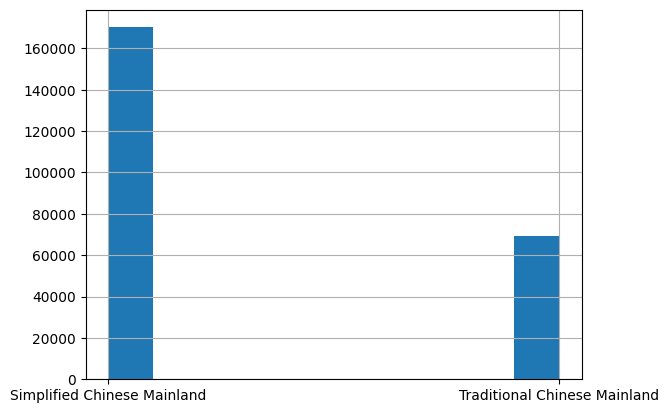

In [22]:
df['Language'].hist()

In [23]:
accepted_df = df[
    (df['Status'] == 'Accepted') & # verified examples
    (df['Language'] == 'Simplified Chinese Mainland') # simplified chars only
].reset_index()

len(accepted_df)

161521

In [24]:
accepted_df.groupby('Topics')['Sr No'].count().sort_values(ascending=False)

Topics
其他新闻News                      71892
社会新闻Social                    22396
政治新闻Political                 19844
文教新闻Culture and Education     13105
经济新闻Economic                  10237
法律新闻Legal                      5877
News                           4093
健康health                       2984
军事新闻Military                   2796
科技新闻Science and Technology     2708
娱乐新闻Entertainment              1598
Political                      1059
Culture and Education           722
体育新闻Sports                      483
旅游Travel                        438
时尚新闻Fashion                     391
音乐Music                         366
Economic                        102
健身Fitness                        99
自助Self Help                      72
Social                           71
Legal                            64
Health                           48
Military                         25
Travel                           18
Science and Technology           15
美丽Beauty                         12
Music                

In [25]:
accepted_df[accepted_df['Topics'] == 'News'].head()

,index,Sr No,Utterance,Status,Language,Topics
151694,250001,2,中国分析人士称，目前对北京来说，更重要的是与杜特地成为朋友，并努力让菲律宾远离与华盛顿缔约的盟约,Accepted,Simplified Chinese Mainland,News
151695,250002,3,这些分析人士表示，在杜特地眼皮底下改变一处沙洲的形态会破坏这种可能性,Accepted,Simplified Chinese Mainland,News
151696,250003,4,“现在把它修成要塞是不理性的，”香港岭南大学国际关系教授张泊汇说,Accepted,Simplified Chinese Mainland,News
151697,250004,5,“政府想让菲律宾在美国与中国的竞争中至少保持中立,Accepted,Simplified Chinese Mainland,News
151703,250012,13,中国和菲律宾都提出对浅滩拥有主权，在越南战争期间，美国曾将这里用作射击训练场,Accepted,Simplified Chinese Mainland,News


## Preprocessing and Labelling

### Examining Quality

In [26]:
import re

# Rows containing at least one digit
has_digit = accepted_df['Utterance'].str.contains(r'\d', na=False, regex=True)

print(f"Total number of sentences with digits: {has_digit.sum()
} ({round(100 * has_digit.sum() / len(accepted_df), 2)}%)")

Total number of sentences with digits: 25230 (15.62%)


In [27]:
# Rows containing at least one punctuation character (excluding spaces)
# Punctuation includes characters like .,!?;:。，！？；：“”‘’ etc.
# Using regex: any character that is not a word character and not whitespace
has_punct = accepted_df['Utterance'].str.contains(r'[^\w\s]', na=False, regex=True)

print(f"Total number of sentences with punctuation: {has_punct.sum()
} ({round(100 * has_punct.sum() / len(accepted_df), 2)}%)")

Total number of sentences with punctuation: 139324 (86.26%)


In [28]:
# Rows containing at least one non-Chinese character (i.e., not in CJK Unified Ideographs block)
# CJK range: \u4e00-\u9fff
# This includes digits, punctuation, Latin letters, etc.
has_non_chinese = accepted_df['Utterance'].str.contains(r'[^\u4e00-\u9fff]', na=False, regex=True)

print(f"Total number of sentences with non-Chinese characters: {has_non_chinese.sum()
} ({round(100 * has_non_chinese.sum() / len(accepted_df), 2)}%)")

Total number of sentences with non-Chinese characters: 141471 (87.59%)


**Proposed changes**: translate digits to Chinese characters, remove punctuation signs (concatenate all characters together), and filter rows that still have non-Chinese characters.

In [29]:
import re

def num_to_chinese(n):
    """Convert integer 0-9999 to Chinese character string."""
    digits = ['零', '一', '二', '三', '四', '五', '六', '七', '八', '九']
    if n == 0:
        return digits[0]
    # up to 4 digits
    units = ['', '十', '百', '千']
    result = []
    for i, unit in enumerate(units):
        digit = (n // (10**i)) % 10
        if digit == 0:
            continue
        if i > 0 and digit == 1 and len(result) == 0 and i == 1:
            # special case: 10 -> 十, not 一十
            result.append(units[i])
        else:
            result.append(digits[digit] + units[i])
    return ''.join(reversed(result))

def clean_text(text):
    # Convert numeric sequences to Chinese characters
    def replace_digits(match):
        num_str = match.group(0)
        num = int(num_str)
        return num_to_chinese(num)

    text = re.sub(r'\d+', replace_digits, text)
    text = re.sub(r'[^\w\s]', '', text)
    cleaned = re.sub(r'\s+', '', text)

    return cleaned

In [30]:
clean_text(accepted_df.loc[0, 'Utterance'])

'一个特殊群体的期待在密切关注此次特金会的人中有一个特殊的群体在日本殖民期间来到日本的韩国朝鲜侨民及他们的后代'

Apply cleaning:

In [31]:
accepted_df['cleaned_utterance'] = accepted_df['Utterance'].apply(clean_text)

In [32]:
# Rows containing at least one non-Chinese character (i.e., not in CJK Unified Ideographs block)
# CJK range: \u4e00-\u9fff
# This includes digits, punctuation, Latin letters, etc.
has_non_chinese = accepted_df['cleaned_utterance'].str.contains(r'[^\u4e00-\u9fff]', na=False, regex=True)

print(f"Total number of sentences with non-Chinese characters (after cleaning): {has_non_chinese.sum()
} ({round(100 * has_non_chinese.sum() / len(accepted_df), 2)}%)")

Total number of sentences with non-Chinese characters (after cleaning): 57 (0.04%)


Examine the special cases:

In [33]:
accepted_df[has_non_chinese]["cleaned_utterance"]

261                                   _委内瑞拉反对派领袖胡安瓜伊多周一返回该国
504                 _四川高山镇一位女性穿行过她家农宅的大门在附近的容县发生的三次地震中大门被毁坏
530                      _二千一十八年七月特朗普与俄罗斯总统弗拉基米尔普京在芬兰赫尔辛基会面
599                               纽约时报_七岁的阿迈勒侯赛因患有严重的急性营养不良
750                                      _今日食谱牛小排丼饭香气浓郁美味健康
1225                                 纽约时报_更多中文内容漫画十字架上的特丽莎梅
1330                       纽约时报_苹果首席执行官蒂姆库克上月在库比蒂诺的史蒂夫乔布斯剧场
1753                      _二千一十六年在他的公司瀚海基因贺建奎展示他编辑的一本书人类基因组
1910              _据官媒朝鲜中央通讯社二千一十八年十月发布的一幅照片朝鲜领导人金正恩在视察三池渊县
1929                   纽约时报_更多中文内容漫画如果林肯读了穆勒报告别再问孩子长大后你想做什么
2233                                             _视频截图里的赵雨思
2290       追溯传统王室新成员的诞生往往会引发巨大_x八_的公众兴趣一些习俗和仪式甚至可以追溯到几个世纪之前
2294                                _特朗普总统指责民主党寻求重启特别检察官的调查
3786                           _特朗普总统和朝鲜领导人金正恩上月在朝韩非军事区举行会晤
3857                                   纽约时报_在火车站买票准备离开东莞的乘客
3967                           纽约时报_鸭绿江上连接朝鲜城市新义州和中国城市丹东的桥梁
4021          纽约时报_一千九百八十九年五月广场上的一张标语小平悬

These sentences are to be removed:

In [34]:
label_df = accepted_df[~has_non_chinese]

print(len(label_df))

161464


In [35]:
for sentence in label_df['cleaned_utterance']:
    predicted = predict_pinyin(sentence, text2pinyin, char2idx, idx2pinyin, device)
    print(f"Input  : {sentence}")
    print(f"Output : {' '.join(predicted)}")
    print()
    break

Input  : 一个特殊群体的期待在密切关注此次特金会的人中有一个特殊的群体在日本殖民期间来到日本的韩国朝鲜侨民及他们的后代
Output : yi1 ge4 te4 shu1 qun2 ti3 de qi1 dai4 zai4 mi4 qie4 guan1 zhu4 ci3 ci4 te4 jin1 hui4 de ren2 zhong1 you3 yi1 ge4 te4 shu1 de qun2 ti3 zai4 ri4 ben3 zhi2 min2 qi1 jian1 lai2 dao4 ri4 ben3 de han2 guo2 chao2 xian1 qiao2 min2 ji2 ta1 men de hou4 dai4



In [36]:
from tqdm import tqdm

pinyin_labels = []
clean_sentences = []

for sentence in tqdm(label_df['cleaned_utterance']):
    predicted = predict_pinyin(sentence, text2pinyin, char2idx, idx2pinyin, device)
    clean_sentences.append(sentence)
    pinyin_labels.append(' '.join(predicted))

100%|██████████| 161464/161464 [05:46<00:00, 466.28it/s]


In [37]:
labelled_dataset = pd.DataFrame({
    'text': clean_sentences,
    'pinyin': pinyin_labels
})

In [38]:
labelled_dataset

,text,pinyin
0,一个特殊群体的期待在密切关注此次特金会的人中有一个特殊的群体在日本殖民期间来到日本的韩国朝鲜...,yi1 ge4 te4 shu1 qun2 ti3 de qi1 dai4 zai4 mi4...
1,他们希望政治解冻有助于让朝鲜摆脱孤立,ta1 men xi1 wang4 zheng4 zhi4 jie3 dong4 you3 ...
2,他认为对这个奖的妄想可能会促使双方做出轻率的承诺但也可能有助于艰巨的和平进程,ta1 ren4 wei2 dui4 zhe4 ge4 jiang3 de wang4 xi...
3,欢迎阅读纪思道文章的中文版,huan1 ying2 yue4 du2 ji4 si1 dao4 wen2 zhang1 ...
4,不法业者向一些中国女性编造了一个美好的未来到美国开始新生活并拥有一份合法的工作,bu4 fa3 ye4 zhe3 xiang4 yi1 xie1 zhong1 guo2 n...
...,...,...
161459,当你有巨大权力而又可以黑箱操作的时候其实人就可以不用那么负责任,dang1 ni3 you3 ju4 da4 quan2 li4 er2 you4 ke3 ...
161460,这批人正试着把自己的权力推出去因为他认为这样才是更朴素公平和正义的,zhe4 pi1 ren2 zheng4 shi4 zhe ba3 zi4 ji3 de q...
161461,但是其实在我们做的时候才明白我们去过审的时候为什么前面稳稳过审只是进行了很多次的调整,dan4 shi4 qi2 shi2 zai4 wo3 men zuo4 de shi2 h...
161462,然后其实我们在这个过程中逐渐才意识到他们允许这个通过是他们知道我们的司法制度正在演进而不是一...,ran2 hou4 qi2 shi2 wo3 men zai4 zhe4 ge4 guo4 ...


In [39]:
# Build character and pinyin vocabularies from the dataset

from tqdm import tqdm

def build_vocab(dataset):
    """
    dataset: list of dicts with keys 'text' (str) and 'pinyin' (str)
    returns:
        char2idx, idx2char, pinyin2idx, idx2pinyin
    """
    # Collect all characters and pinyin tokens
    chars = set()
    pinyins = set()
    
    for i, sample in tqdm(dataset.iterrows(), total=len(dataset)):
        text = sample['text']
        pinyin_str = sample['pinyin']
        
        # Add each character from text
        for ch in text:
            chars.add(ch)
        
        # Split pinyin by space and add each token
        tokens = pinyin_str.split()
        for tok in tokens:
            if (
                (tok[-1].isdigit() and tok[:-1] in pinyin_tokens) or \
                (tok[-1].isalpha() and tok in pinyin_tokens)
            ):
                pinyins.add(tok)
    
    # Convert to sorted lists for deterministic order (optional)
    char_list = ['<UNK>', '<PAD>'] + sorted(chars)
    pinyin_list = ['<UNK>', '<PAD>'] + sorted(pinyins)
    
    # Create mappings
    char2idx = {ch: idx for idx, ch in enumerate(char_list)}
    idx2char = {idx: ch for idx, ch in enumerate(char_list)}
    
    pinyin2idx = {p: idx for idx, p in enumerate(pinyin_list)}
    idx2pinyin = {idx: p for idx, p in enumerate(pinyin_list)}
    
    print(f"Number of unique characters (including specials): {len(char_list)}")
    print(f"Number of unique pinyin tokens (including specials): {len(pinyin_list)}")

    return char2idx, idx2char, pinyin2idx, idx2pinyin

In [40]:
char2idx, idx2char, pinyin2idx, idx2pinyin = build_vocab(labelled_dataset)

100%|██████████| 161464/161464 [00:07<00:00, 20238.40it/s]

Number of unique characters (including specials): 5466
Number of unique pinyin tokens (including specials): 1105


In [41]:
labelled_dataset.to_csv("chinese-short-sentences-pinyin.csv", index=False)